In [1]:
import pandas as pd
import numpy as np
from statsmodels.api import OLS, add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Charger vos données
df = pd.read_excel('data/var_auxi.xlsx')  # ← ADAPTER LE NOM DU FICHIER

In [4]:
# Renommer les colonnes pour faciliter l'accès
df.rename(columns={
    "taux_pauvrete_MD":"H_dept",
    "distance_hopital (km)":"dist_hopital",
    "distance_école (km)":"dist_ecole",
    "pop_density_2020 (hbts/km2)":"densite_pop",
    "light_mean_2023 (nW/cm²/sr) (Lumière par surface ET par direction)":"night_light",
    "distance_roads_mean (km)":"dist_roads",
    "Rendmnt_mil_Kg/ha":"rend_mil",
    "Rendmnt_riz_Kg/ha":"rend_riz",
    "Rendmnt_mais_Kg/ha":"rend_mais",
    "Rendmnt_sorgho_Kg/ha":"rend_sorgho"
}, inplace=True)

In [5]:

print("="*80)
print("DONNÉES CHARGÉES")
print("="*80)
print(f"Nombre de départements : {len(df)}")
print(f"\nPremières lignes :")
print(df[['departement', 'H_dept', 'variance_directe']].head())

DONNÉES CHARGÉES
Nombre de départements : 45

Premières lignes :
  departement    H_dept  variance_directe
0       DAKAR  0.088046          0.000038
1      PIKINE  0.144098          0.000058
2    RUFISQUE  0.295463          0.000301
3  GUEDIAWAYE  0.145442          0.000236
4     BIGNONA  0.413044          0.000187


In [6]:
# Variables
target = 'H_dept'
variance_col = 'variance_directe'
# Liste de toutes vos variables auxiliaires candidates
auxiliaires = [ 'alpha_pct',
                'taux_emploi_pct',
                'ratio_dep',
                'handicap_pct',
                'elec_pct',
                'eau_pct',
                'toilette_pct',
                'logt_pct',
                'equip_dep',
                'insa_alim_pct',
                'dist_hopital',
                'dist_ecole',
                'densite_pop',
                'night_light',
                'dist_roads',
                'rend_mil',
                'rend_mais',
                'rend_sorgho',
                'rend_riz']

## Vérifier qu'il n'y a pas de valeurs manquantes

In [7]:
print("\n" + "-"*80)
print("Vérification des valeurs manquantes :")
print("-"*80)
missing = df[auxiliaires + [target, variance_col]].isnull().sum()
if missing.sum() > 0:
    print("⚠️ Variables avec valeurs manquantes :")
    print(missing[missing > 0])
    print("\n→ Considérez l'imputation ou le retrait de ces variables")
else:
    print("✓ Aucune valeur manquante")


--------------------------------------------------------------------------------
Vérification des valeurs manquantes :
--------------------------------------------------------------------------------
✓ Aucune valeur manquante


##  Stat desc

In [18]:
print("\n" + "="*80)
print("STATISTIQUES DESCRIPTIVES")
print("="*80)

print(f"\nVariable cible : {target}")
print(df[target].describe())

print(f"\nVariance : {variance_col}")
print(df[variance_col].describe())


STATISTIQUES DESCRIPTIVES

Variable cible : H_dept
count   45.000000
mean     0.568004
std      0.210208
min      0.088046
25%      0.474292
50%      0.613800
75%      0.694698
max      0.949338
Name: H_dept, dtype: float64

Variance : variance_directe
count   45.000000
mean     0.000256
std      0.000273
min      0.000038
25%      0.000136
50%      0.000187
75%      0.000251
max      0.001802
Name: variance_directe, dtype: float64


## 4. ANALYSE DES CORRÉLATIONS

In [19]:
print("\n" + "="*80)
print("ÉTAPE 1 : ANALYSE DES CORRÉLATIONS")
print("="*80)

# Corrélations avec H_dept
correlations = df[auxiliaires].corrwith(df[target]).sort_values(
    ascending=False, key=abs
)

print("\n Top 10 variables les plus corrélées avec H_dept :")
print("-"*80)
for i, (var, corr) in enumerate(correlations.head(10).items(), 1):
    direction = "↑ positive" if corr > 0 else "↓ négative"
    print(f"{i:2d}. {var:25s} : {corr:7.4f}  {direction}")

print("\n⚠️ Variables faiblement corrélées (|r| < 0.3) :")
faibles = correlations[abs(correlations) < 0.3]
if len(faibles) > 0:
    for var, corr in faibles.items():
        print(f"  - {var:25s} : {corr:7.4f}")
    print(f"\n→ Ces {len(faibles)} variables seront probablement exclues par le stepwise")
else:
    print("  ✓ Aucune")

# Matrice de corrélation (optionnel - pour graphique)
print("\n Création de la matrice de corrélation...")
plt.figure(figsize=(14, 12))
corr_matrix = df[auxiliaires].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Matrice de corrélation des variables auxiliaires', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Fichier 'correlation_matrix.png' créé")
plt.close()


ÉTAPE 1 : ANALYSE DES CORRÉLATIONS

 Top 10 variables les plus corrélées avec H_dept :
--------------------------------------------------------------------------------
 1. alpha_pct                 : -0.8349  ↓ négative
 2. elec_pct                  : -0.7747  ↓ négative
 3. equip_dep                 : -0.7561  ↓ négative
 4. toilette_pct              : -0.7176  ↓ négative
 5. taux_emploi_pct           : -0.6592  ↓ négative
 6. dist_ecole                :  0.6585  ↑ positive
 7. logt_pct                  : -0.6521  ↓ négative
 8. night_light               : -0.6035  ↓ négative
 9. densite_pop               : -0.5852  ↓ négative
10. rend_sorgho               :  0.5550  ↑ positive

⚠️ Variables faiblement corrélées (|r| < 0.3) :
  - dist_roads                :  0.2528
  - rend_riz                  :  0.1947
  - ratio_dep                 : -0.0571

→ Ces 3 variables seront probablement exclues par le stepwise

 Création de la matrice de corrélation...
✓ Fichier 'correlation_matrix.png' c

## 5. FONCTION STEPWISE

In [20]:
def stepwise_selection_ipm(X, y, variances, 
                          threshold_in=0.05, 
                          threshold_out=0.10,
                          max_vars=None,
                          verbose=True):
    """
    Sélection stepwise bidirectionnelle avec régression pondérée
    """
    
    # Nombre max de variables (règle : n/10 pour 45 depts = 4-5 vars max)
    if max_vars is None:
        max_vars = max(3, len(y) // 10)
    
    weights = 1 / variances
    included = []
    
    if verbose:
        print(f"\n{'='*80}")
        print(f"SÉLECTION STEPWISE")
        print(f"{'='*80}")
        print(f"Seuil d'entrée (α)  : {threshold_in}")
        print(f"Seuil de sortie     : {threshold_out}")
        print(f"Variables max       : {max_vars}")
        print(f"Observations        : {len(y)}")
        print(f"{'='*80}\n")
    
    iteration = 0
    
    while True:
        iteration += 1
        changed = False
        
        if verbose:
            print(f"\n{'─'*80}")
            print(f"Itération {iteration}")
            print(f"{'─'*80}")
            if included:
                print(f"Variables actuelles : {', '.join(included)}")
            else:
                print(f"Variables actuelles : Aucune")
        
        # FORWARD STEP
        if len(included) < max_vars:
            excluded = list(set(X.columns) - set(included))
            
            if len(excluded) > 0:
                new_pval = pd.Series(index=excluded, dtype=float)
                
                for new_column in excluded:
                    test_vars = included + [new_column]
                    model = OLS(y, add_constant(X[test_vars]), 
                               weights=weights).fit()
                    new_pval[new_column] = model.pvalues[new_column]
                
                best_pval = new_pval.min()
                
                if best_pval < threshold_in:
                    best_feature = new_pval.idxmin()
                    included.append(best_feature)
                    changed = True
                    
                    if verbose:
                        print(f"  ✓ AJOUT : {best_feature}")
                        print(f"    └─ p-value = {best_pval:.6f}")
        
        # BACKWARD STEP
        if len(included) > 0:
            model = OLS(y, add_constant(X[included]), weights=weights).fit()
            pvalues = model.pvalues.iloc[1:]
            
            worst_pval = pvalues.max()
            
            if worst_pval > threshold_out:
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
                changed = True
                
                if verbose:
                    print(f"  ✗ RETRAIT : {worst_feature}")
                    print(f"    └─ p-value = {worst_pval:.6f}")
        
        if not changed:
            if verbose:
                print(f"\n  → Convergence atteinte")
            break
    
    # Résultats finaux
    if len(included) == 0:
        print("\n ATTENTION : Aucune variable sélectionnée !")
        print("   → Essayez d'assouplir le seuil (threshold_in=0.10)")
        return None
    
    final_model = OLS(y, add_constant(X[included]), weights=weights).fit()
    
    results = {
        'variables': included,
        'n_vars': len(included),
        'model': final_model,
        'r_squared': final_model.rsquared,
        'r_squared_adj': final_model.rsquared_adj,
        'aic': final_model.aic,
        'bic': final_model.bic,
        'coefficients': final_model.params[1:],
        'pvalues': final_model.pvalues[1:],
        'std_errors': final_model.bse[1:]
    }
    
    return results


## 6. EXÉCUTION DU STEPWISE

In [27]:
print("\n" + "="*80)
print("ÉTAPE 2 : SÉLECTION STEPWISE")
print("="*80)

results = stepwise_selection_ipm(
    X=df[auxiliaires],
    y=df[target],
    variances=df[variance_col],
    threshold_in=0.05,
    threshold_out=0.10,
    max_vars=None,  # Laisse calculer automatiquement (45/10 ≈ 4-5)
    verbose=True
)


ÉTAPE 2 : SÉLECTION STEPWISE

SÉLECTION STEPWISE
Seuil d'entrée (α)  : 0.05
Seuil de sortie     : 0.1
Variables max       : 4
Observations        : 45


────────────────────────────────────────────────────────────────────────────────
Itération 1
────────────────────────────────────────────────────────────────────────────────
Variables actuelles : Aucune
  ✓ AJOUT : alpha_pct
    └─ p-value = 0.000000

────────────────────────────────────────────────────────────────────────────────
Itération 2
────────────────────────────────────────────────────────────────────────────────
Variables actuelles : alpha_pct
  ✓ AJOUT : taux_emploi_pct
    └─ p-value = 0.000024

────────────────────────────────────────────────────────────────────────────────
Itération 3
────────────────────────────────────────────────────────────────────────────────
Variables actuelles : alpha_pct, taux_emploi_pct
  ✓ AJOUT : rend_mais
    └─ p-value = 0.005937

─────────────────────────────────────────────────────────────

## Affichage 

In [22]:
if results is not None:
    print("\n" + "="*80)
    print("RÉSULTATS FINAUX")
    print("="*80)
    
    print(f"\n Variables sélectionnées : {results['n_vars']}")
    print(f" R² (pondéré)      : {results['r_squared']:.4f}")
    print(f" R² ajusté         : {results['r_squared_adj']:.4f}")
    print(f" AIC               : {results['aic']:.2f}")
    print(f" BIC               : {results['bic']:.2f}")
    
    print("\n" + "─"*80)
    print("Tableau des coefficients :")
    print("─"*80)
    
    results_table = pd.DataFrame({
        'Variable': results['variables'],
        'Coefficient': results['coefficients'].values,
        'Std_Error': results['std_errors'].values,
        'p_value': results['pvalues'].values,
        't_stat': results['coefficients'].values / results['std_errors'].values
    })
    
    def sig_level(p):
        if p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        elif p < 0.10:
            return '·'
        else:
            return 'ns'
    
    results_table['Signif'] = results_table['p_value'].apply(sig_level)
    
    # Format pour affichage
    pd.options.display.float_format = '{:.6f}'.format
    print(results_table.to_string(index=False))
    print("\nSignificativité : *** p<0.001 ; ** p<0.01 ; * p<0.05 ; · p<0.10")


RÉSULTATS FINAUX

 Variables sélectionnées : 3
 R² (pondéré)      : 1.0000
 R² ajusté         : 1.0000
 AIC               : -87.12
 BIC               : -79.90

────────────────────────────────────────────────────────────────────────────────
Tableau des coefficients :
────────────────────────────────────────────────────────────────────────────────
       Variable  Coefficient  Std_Error  p_value    t_stat Signif
      alpha_pct    -1.033988   0.106179 0.000000 -9.738202    ***
taux_emploi_pct    -0.715329   0.229677 0.003356 -3.114492     **
      rend_mais     0.000036   0.000012 0.005937  2.902276     **

Significativité : *** p<0.001 ; ** p<0.01 ; * p<0.05 ; · p<0.10


## Vérification VIF

In [13]:
if results is not None and results['n_vars'] > 1:
    print("\n" + "="*80)
    print("ÉTAPE 3 : VÉRIFICATION MULTICOLLINÉARITÉ (VIF)")
    print("="*80)
    
    selected_vars = results['variables']
    vif_data = pd.DataFrame()
    vif_data['Variable'] = selected_vars
    vif_data['VIF'] = [
        variance_inflation_factor(df[selected_vars].values, i) 
        for i in range(len(selected_vars))
    ]
    vif_data = vif_data.sort_values('VIF', ascending=False)
    
    print("\n")
    print(vif_data.to_string(index=False))
    
    print("\nInterprétation :")
    print("  VIF < 5  : ✓ Acceptable")
    print("  VIF 5-10 : ⚠️ Multicollinéarité modérée")
    print("  VIF > 10 : ✗ Multicollinéarité sévère (retirer la variable)")
    
    if (vif_data['VIF'] > 10).any():
        problematic = vif_data[vif_data['VIF'] > 10]['Variable'].tolist()
        print(f"\n⚠️ ATTENTION : Multicollinéarité sévère détectée")
        print(f"   Variables problématiques : {', '.join(problematic)}")
        print(f"   → Relancer le stepwise en excluant ces variables")
    elif (vif_data['VIF'] > 5).any():
        moderate = vif_data[vif_data['VIF'] > 5]['Variable'].tolist()
        print(f"\n⚠️ Multicollinéarité modérée pour : {', '.join(moderate)}")
        print(f"   → Acceptable mais à surveiller")
    else:
        print("\n✓ Toutes les variables ont VIF < 5 : EXCELLENT !")



ÉTAPE 3 : VÉRIFICATION MULTICOLLINÉARITÉ (VIF)


       Variable      VIF
taux_emploi_pct 7.847581
      alpha_pct 7.451292
      rend_mais 2.289480

Interprétation :
  VIF < 5  : ✓ Acceptable
  VIF 5-10 : ⚠️ Multicollinéarité modérée
  VIF > 10 : ✗ Multicollinéarité sévère (retirer la variable)

⚠️ Multicollinéarité modérée pour : taux_emploi_pct, alpha_pct
   → Acceptable mais à surveiller


## 9. DIAGNOSTICS GRAPHIQUES


ÉTAPE 4 : DIAGNOSTICS GRAPHIQUES


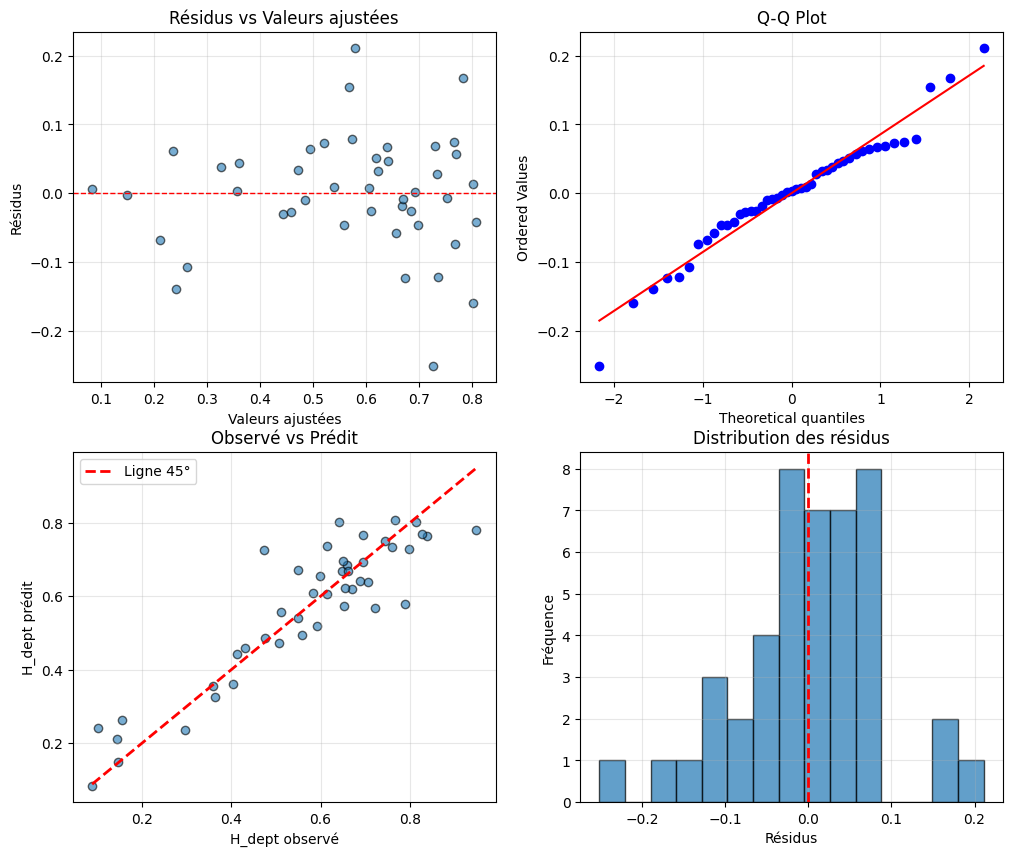

In [15]:
if results is not None:
    print("\n" + "="*80)
    print("ÉTAPE 4 : DIAGNOSTICS GRAPHIQUES")
    print("="*80)
    
    # Résidus vs fitted values
    fitted = results['model'].fittedvalues
    residuals = results['model'].resid
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 1. Résidus vs valeurs ajustées
    axes[0, 0].scatter(fitted, residuals, alpha=0.6, edgecolors='k')
    axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=1)
    axes[0, 0].set_xlabel('Valeurs ajustées')
    axes[0, 0].set_ylabel('Résidus')
    axes[0, 0].set_title('Résidus vs Valeurs ajustées')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Q-Q plot
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Q-Q Plot')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. H_dept observé vs prédit
    axes[1, 0].scatter(df[target], fitted, alpha=0.6, edgecolors='k')
    axes[1, 0].plot([df[target].min(), df[target].max()], 
                     [df[target].min(), df[target].max()], 
                     'r--', linewidth=2, label='Ligne 45°')
    axes[1, 0].set_xlabel('H_dept observé')
    axes[1, 0].set_ylabel('H_dept prédit')
    axes[1, 0].set_title('Observé vs Prédit')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Distribution des résidus
    axes[1, 1].hist(residuals, bins=15, edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1, 1].set_xlabel('Résidus')
    axes[1, 1].set_ylabel('Fréquence')
    axes[1, 1].set_title('Distribution des résidus')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.show()

    #plt.tight_layout()
    #plt.savefig('diagnostics_stepwise.png', dpi=300, bbox_inches='tight')
    #print("\n✓ Fichier 'diagnostics_stepwise.png' créé")
    #plt.close()

In [28]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [29]:
y_var = "H_dept"

vars_candidates = [
    "alpha_pct", "taux_emploi_pct", "ratio_dep", "handicap_pct",
    "elec_pct", "eau_pct", "toilette_pct", "logt_pct", "equip_dep",
    "insa_alim_pct",
    "dist_hopital", "dist_ecole", "dist_roads",
    "densite_pop", "night_light",
    "rend_mil", "rend_mais", "rend_sorgho", "rend_riz"
]


In [31]:
def compute_vif(df, variables):
    X = sm.add_constant(df[variables])
    vif = pd.DataFrame({
        "variable": X.columns,
        "VIF": [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })
    return vif[vif["variable"] != "const"]


In [43]:
vif_table = compute_vif(df, vars_candidates)
vif_table.sort_values("VIF", ascending=False, inplace=True)
vif_table


,variable,VIF
9,equip_dep,52.507109
5,elec_pct,43.379001
7,toilette_pct,24.369141
2,taux_emploi_pct,20.167151
15,night_light,13.177714
14,densite_pop,12.144421
8,logt_pct,12.103836
10,insa_alim_pct,10.267035
6,eau_pct,10.042553
3,ratio_dep,9.330629


In [44]:
vars_vif_ok = vif_table.loc[vif_table["VIF"] < 10, "variable"].tolist()
vars_vif_ok


['ratio_dep',
 'rend_mais',
 'dist_ecole',
 'alpha_pct',
 'rend_mil',
 'rend_sorgho',
 'handicap_pct',
 'dist_hopital',
 'dist_roads',
 'rend_riz']

In [34]:
def stepwise_bic(X, y):
    remaining = list(X.columns)
    selected = []
    current_bic = np.inf

    while len(remaining) > 0:
        bic_candidates = []

        for var in remaining:
            X_test = sm.add_constant(X[selected + [var]])
            model = sm.OLS(y, X_test).fit()
            bic_candidates.append((model.bic, var))

        bic_candidates.sort()
        best_bic, best_var = bic_candidates[0]

        if best_bic < current_bic:
            current_bic = best_bic
            selected.append(best_var)
            remaining.remove(best_var)
        else:
            break

    return selected


In [35]:
X = df[vars_vif_ok]
y = df[y_var]

vars_selectionnees = stepwise_bic(X, y)
vars_selectionnees


['alpha_pct', 'rend_mais', 'handicap_pct']

In [36]:
print("Variables candidates initiales :", vars_candidates)
print("Variables après VIF :", vars_vif_ok)
print("Variables sélectionnées par stepwise BIC :", vars_selectionnees)


Variables candidates initiales : ['alpha_pct', 'taux_emploi_pct', 'ratio_dep', 'handicap_pct', 'elec_pct', 'eau_pct', 'toilette_pct', 'logt_pct', 'equip_dep', 'insa_alim_pct', 'dist_hopital', 'dist_ecole', 'dist_roads', 'densite_pop', 'night_light', 'rend_mil', 'rend_mais', 'rend_sorgho', 'rend_riz']
Variables après VIF : ['alpha_pct', 'ratio_dep', 'handicap_pct', 'dist_hopital', 'dist_ecole', 'dist_roads', 'rend_mil', 'rend_mais', 'rend_sorgho', 'rend_riz']
Variables sélectionnées par stepwise BIC : ['alpha_pct', 'rend_mais', 'handicap_pct']


In [37]:
def stepwise_aic(X, y):
    remaining = list(X.columns)
    selected = []
    current_aic = np.inf

    while len(remaining) > 0:
        aic_candidates = []

        for var in remaining:
            X_test = sm.add_constant(X[selected + [var]])
            model = sm.OLS(y, X_test).fit()
            aic_candidates.append((model.aic, var))

        aic_candidates.sort()
        best_aic, best_var = aic_candidates[0]

        if best_aic < current_aic:
            current_aic = best_aic
            selected.append(best_var)
            remaining.remove(best_var)
        else:
            break

    return selected


In [38]:
vars_selectionnees = stepwise_aic(X, y)
len(vars_selectionnees), vars_selectionnees


(3, ['alpha_pct', 'rend_mais', 'handicap_pct'])

In [39]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def cv_rmse(model, X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []

    for train, test in kf.split(X):
        model.fit(X.iloc[train], y.iloc[train])
        pred = model.predict(X.iloc[test])
        rmses.append(np.sqrt(mean_squared_error(y.iloc[test], pred)))

    return np.mean(rmses)


In [40]:
from sklearn.linear_model import LinearRegression

def stepwise_cv(X, y, max_vars=10):
    remaining = list(X.columns)
    selected = []
    best_rmse = np.inf

    while remaining and len(selected) < max_vars:
        rmse_candidates = []

        for var in remaining:
            X_test = X[selected + [var]]
            rmse = cv_rmse(LinearRegression(), X_test, y)
            rmse_candidates.append((rmse, var))

        rmse_candidates.sort()
        rmse, best_var = rmse_candidates[0]

        if rmse < best_rmse:
            best_rmse = rmse
            selected.append(best_var)
            remaining.remove(best_var)
        else:
            break

    return selected


In [41]:
vars_selectionnees = stepwise_cv(X, y, max_vars=10)
len(vars_selectionnees), vars_selectionnees


(4, ['alpha_pct', 'rend_mais', 'ratio_dep', 'rend_mil'])